In [1]:
pip install pandas numpy scikit-learn matplotlib transformers torch flask joblib nltk

In [2]:
import pandas as pd
import numpy as np
import re
import joblib
import matplotlib.pyplot as plt

from datetime import datetime
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForSequenceClassification


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


### Load Data

In [21]:
news_df = pd.read_csv("/content/india-news-headlines.csv")
stock_df = pd.read_csv("/content/stock_data.csv")

In [22]:
news_df

,publish_date,headline_category,headline_text
0,20010102,unknown,Status quo will not be disturbed at Ayodhya; s...
1,20010102,unknown,Fissures in Hurriyat over Pak visit
2,20010102,unknown,America's unwanted heading for India?
3,20010102,unknown,For bigwigs; it is destination Goa
4,20010102,unknown,Extra buses to clear tourist traffic
...,...,...,...
30031,20210113,city.hyderabad,Bonsai stolen from ex-cop's house
30032,20210113,city.madurai,Man asked to deposit Rs 50k in sand mining case
30033,20210113,city.madurai,Delay in appointing temporary staff would dera...
30034,20210113,city.madurai,Addl facilities made to help pilgrims to Palan...


In [23]:
news_df.tail()


,publish_date,headline_category,headline_text
30031,20210113,city.hyderabad,Bonsai stolen from ex-cop's house
30032,20210113,city.madurai,Man asked to deposit Rs 50k in sand mining case
30033,20210113,city.madurai,Delay in appointing temporary staff would dera...
30034,20210113,city.madurai,Addl facilities made to help pilgrims to Palan...
30035,2021,NaN,NaN


In [24]:
news_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30036 entries, 0 to 30035
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   publish_date       30036 non-null  int64 
 1   headline_category  30035 non-null  object
 2   headline_text      30035 non-null  object
dtypes: int64(1), object(2)
memory usage: 704.1+ KB


In [25]:
stock_df

,Date,Open,High,Low,Close,Adj Close,Volume
0,"May 6, 2024","74,196.68","74,359.69","73,786.29","73,895.54","73,895.54","11,200"
1,"May 3, 2024","75,017.82","75,095.18","73,467.73","73,878.15","73,878.15","15,600"
2,"May 2, 2024","74,391.73","74,812.43","74,360.69","74,611.11","74,611.11","18,400"
3,"Apr 30, 2024","74,800.89","75,111.39","74,346.40","74,482.78","74,482.78","8,400"
4,"Apr 29, 2024","73,982.75","74,721.15","73,922.34","74,671.28","74,671.28","9,900"
...,...,...,...,...,...,...,...
5744,"Jan 8, 2001","4,164.76","4,206.72","4,101.53","4,120.43","4,120.43",-
5745,"Jan 5, 2001","4,116.34","4,195.01","4,115.35","4,183.73","4,183.73",-
5746,"Jan 4, 2001","4,180.97","4,180.97","4,109.55","4,115.37","4,115.37",-
5747,"Jan 3, 2001","3,977.58","4,067.66","3,977.58","4,060.02","4,060.02",-


In [26]:
stock_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5749 entries, 0 to 5748
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Date       5749 non-null   object
 1   Open       5749 non-null   object
 2   High       5749 non-null   object
 3   Low        5749 non-null   object
 4   Close      5749 non-null   object
 5   Adj Close  5749 non-null   object
 6   Volume     5749 non-null   object
dtypes: object(7)
memory usage: 314.5+ KB


In [27]:
stock_df.describe()

,Date,Open,High,Low,Close,Adj Close,Volume
count,5749,5749,5749,5749,5749,5749,5749
unique,5749,5735,5744,5745,5744,5744,482
top,"Jan 2, 2001","17,402.24","3,435.68","9,271.63","16,677.88","16,677.88",-
freq,1,2,2,2,2,2,633


## Text Cleaning

In [28]:
stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return ' '.join(w for w in text.split() if w not in stop_words)

# Use the ACTUAL column names from CSV
news_df = news_df[['publish_date', 'headline_text']].copy()

# Convert publish_date → datetime
news_df['publish_date'] = pd.to_datetime(
    news_df['publish_date'].astype(str),
    format='%Y%m%d',
    errors='coerce'
)

# Rename AFTER conversion
news_df.rename(columns={'publish_date': 'Date'}, inplace=True)

# Remove bad rows
news_df.dropna(subset=['Date', 'headline_text'], inplace=True)

# Remove duplicates
news_df.drop_duplicates(inplace=True)

# Clean headlines
news_df['cleaned_headline'] = news_df['headline_text'].apply(clean_text)

news_df.head()


,Date,headline_text,cleaned_headline
0,2001-01-02,Status quo will not be disturbed at Ayodhya; s...,status quo disturbed ayodhya says vajpayee
1,2001-01-02,Fissures in Hurriyat over Pak visit,fissures hurriyat pak visit
2,2001-01-02,America's unwanted heading for India?,americas unwanted heading india
3,2001-01-02,For bigwigs; it is destination Goa,bigwigs destination goa
4,2001-01-02,Extra buses to clear tourist traffic,extra buses clear tourist traffic


In [29]:
news_df

,Date,headline_text,cleaned_headline
0,2001-01-02,Status quo will not be disturbed at Ayodhya; s...,status quo disturbed ayodhya says vajpayee
1,2001-01-02,Fissures in Hurriyat over Pak visit,fissures hurriyat pak visit
2,2001-01-02,America's unwanted heading for India?,americas unwanted heading india
3,2001-01-02,For bigwigs; it is destination Goa,bigwigs destination goa
4,2001-01-02,Extra buses to clear tourist traffic,extra buses clear tourist traffic
...,...,...,...
30030,2021-01-13,HC modifies punishment for physical edu teacher,hc modifies punishment physical edu teacher
30031,2021-01-13,Bonsai stolen from ex-cop's house,bonsai stolen excops house
30032,2021-01-13,Man asked to deposit Rs 50k in sand mining case,man asked deposit rs k sand mining case
30033,2021-01-13,Delay in appointing temporary staff would dera...,delay appointing temporary staff would derail ...


In [30]:
print(f"Original news_df date range: {news_df['Date'].min()} to {news_df['Date'].max()}")


Original news_df date range: 2001-01-02 00:00:00 to 2021-01-13 00:00:00


In [31]:
!huggingface-cli login

⚠️  Warning: 'huggingface-cli login' is deprecated. Use 'hf auth login' instead.

    _|    _|  _|    _|    _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|_|_|_|    _|_|      _|_|_|  _|_|_|_|
    _|    _|  _|    _|  _|        _|          _|    _|_|    _|  _|            _|        _|    _|  _|        _|
    _|_|_|_|  _|    _|  _|  _|_|  _|  _|_|    _|    _|  _|  _|  _|  _|_|      _|_|_|    _|_|_|_|  _|        _|_|_|
    _|    _|  _|    _|  _|    _|  _|    _|    _|    _|    _|_|  _|    _|      _|        _|    _|  _|        _|
    _|    _|    _|_|      _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|        _|    _|    _|_|_|  _|_|_|_|

    A token is already saved on your machine. Run `hf auth whoami` to get more information or `hf auth logout` if you want to log out.
    Setting a new token will erase the existing one.
    To log in, `huggingface_hub` requires a token generated from https://huggingface.co/settings/tokens .
Enter your token (input will not be visible): 
Add t

### FinBERT SENTIMENT (PRIMARY)

In [33]:
demo_df = news_df.sample(n=2000, random_state=42).reset_index(drop=True)

demo_df.shape


(2000, 3)

In [34]:
news_df2=demo_df.copy()

In [35]:
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import pandas as pd

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tokenizer = AutoTokenizer.from_pretrained("ProsusAI/finbert")
model = AutoModelForSequenceClassification.from_pretrained("ProsusAI/finbert")
model.to(device)
model.eval()

labels = ['negative', 'neutral', 'positive']


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [36]:
def finbert_sentiment_batch(texts, batch_size=32):
    results = []

    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i+batch_size]

        inputs = tokenizer(
            batch_texts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=128
        ).to(device)

        with torch.no_grad():
            outputs = model(**inputs)
            probs = F.softmax(outputs.logits, dim=1)

        results.extend(probs.cpu().numpy())

    return results


In [37]:
probs = finbert_sentiment_batch(
    news_df2['cleaned_headline'].tolist(),
    batch_size=32  # use 64 if GPU has enough VRAM
)

news_df2[['fin_neg','fin_neu','fin_pos']] = pd.DataFrame(
    probs, columns=labels, index=news_df2.index
)

news_df2['finbert_score'] = news_df2['fin_pos'] - news_df2['fin_neg']


In [38]:
news_df2

,Date,headline_text,cleaned_headline,fin_neg,fin_neu,fin_pos,finbert_score
0,2001-08-09,Haasil: Tackling 'true love'!,haasil tackling true love,0.154047,0.058050,0.787903,0.633856
1,2020-12-20,Muslim man held for posing as Hindu to marry g...,muslim man held posing hindu marry girl ups ka...,0.058369,0.119049,0.822583,0.764214
2,2001-03-25,An ode to Apu,ode apu,0.085134,0.032970,0.881895,0.796761
3,2001-05-01,One role; many dimensions,one role many dimensions,0.041842,0.065744,0.892414,0.850571
4,2001-08-02,Sino-India border talks conclude,sinoindia border talks conclude,0.255181,0.017449,0.727370,0.472189
...,...,...,...,...,...,...,...
1995,2001-08-09,Discovery all set to launch a new channel,discovery set launch new channel,0.052246,0.020354,0.927401,0.875155
1996,2001-08-18,UN polio campaign in Afghanistan,un polio campaign afghanistan,0.050714,0.056428,0.892858,0.842144
1997,2001-08-17,Railway mulls surcharge on passenger tickets,railway mulls surcharge passenger tickets,0.034005,0.087668,0.878327,0.844322
1998,2001-08-17,Minor girl killed; 3 others injured,minor girl killed others injured,0.019985,0.864386,0.115629,0.095643


### LLM-BASED SENTIMENT (SECONDARY – GenAI)

In [ ]:
'''
For offline purposes
def llm_sentiment_mock(text):
    if any(word in text for word in ['crash','loss','fall','decline']):
        return -1
    elif any(word in text for word in ['growth','profit','rise','gain']):
        return 1
    else:
        return 0

news_df['llm_sentiment'] = news_df['cleaned_headline'] \
    .apply(llm_sentiment_mock)
'''

In [41]:
import torch
from transformers import pipeline

device = 0 if torch.cuda.is_available() else -1

llm = pipeline(
    "text2text-generation",
    model="google/flan-t5-base",
    device=device
)


Device set to use cuda:0


In [42]:
def llm_sentiment_batch(texts, batch_size=8):
    sentiments = []

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]

        prompts = [
            f"Classify sentiment (Positive, Neutral, Negative): {t}"
            for t in batch
        ]

        with torch.no_grad():
            outputs = llm(
                prompts,
                max_new_tokens=3,
                do_sample=False
            )

        for out in outputs:
            text = out["generated_text"].lower()
            if "positive" in text:
                sentiments.append(1)
            elif "negative" in text:
                sentiments.append(-1)
            else:
                sentiments.append(0)

    return sentiments


In [43]:
news_df2["llm_sentiment"] = llm_sentiment_batch(
    news_df2["cleaned_headline"].tolist(),
    batch_size=16
)


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


In [44]:
news_df2

,Date,headline_text,cleaned_headline,fin_neg,fin_neu,fin_pos,finbert_score,llm_sentiment
0,2001-08-09,Haasil: Tackling 'true love'!,haasil tackling true love,0.154047,0.058050,0.787903,0.633856,1
1,2020-12-20,Muslim man held for posing as Hindu to marry g...,muslim man held posing hindu marry girl ups ka...,0.058369,0.119049,0.822583,0.764214,1
2,2001-03-25,An ode to Apu,ode apu,0.085134,0.032970,0.881895,0.796761,1
3,2001-05-01,One role; many dimensions,one role many dimensions,0.041842,0.065744,0.892414,0.850571,1
4,2001-08-02,Sino-India border talks conclude,sinoindia border talks conclude,0.255181,0.017449,0.727370,0.472189,1
...,...,...,...,...,...,...,...,...
1995,2001-08-09,Discovery all set to launch a new channel,discovery set launch new channel,0.052246,0.020354,0.927401,0.875155,1
1996,2001-08-18,UN polio campaign in Afghanistan,un polio campaign afghanistan,0.050714,0.056428,0.892858,0.842144,1
1997,2001-08-17,Railway mulls surcharge on passenger tickets,railway mulls surcharge passenger tickets,0.034005,0.087668,0.878327,0.844322,-1
1998,2001-08-17,Minor girl killed; 3 others injured,minor girl killed others injured,0.019985,0.864386,0.115629,0.095643,-1


In [45]:
news_df2.head(30)

,Date,headline_text,cleaned_headline,fin_neg,fin_neu,fin_pos,finbert_score,llm_sentiment
0,2001-08-09,Haasil: Tackling 'true love'!,haasil tackling true love,0.154047,0.058050,0.787903,0.633856,1
1,2020-12-20,Muslim man held for posing as Hindu to marry g...,muslim man held posing hindu marry girl ups ka...,0.058369,0.119049,0.822583,0.764214,1
2,2001-03-25,An ode to Apu,ode apu,0.085134,0.032970,0.881895,0.796761,1
3,2001-05-01,One role; many dimensions,one role many dimensions,0.041842,0.065744,0.892414,0.850571,1
4,2001-08-02,Sino-India border talks conclude,sinoindia border talks conclude,0.255181,0.017449,0.727370,0.472189,1
5,2001-07-25,Israel awaits President K R Narayanan's visit,israel awaits president k r narayanans visit,0.114891,0.039329,0.845780,0.730890,1
6,2001-05-29,Lankan match-fixing report by mid June,lankan matchfixing report mid june,0.034701,0.072944,0.892355,0.857654,1
7,2020-12-21,Goa: Beef starts trickling in; but traders uns...,goa beef starts trickling traders unsure long,0.069345,0.687564,0.243091,0.173745,1
8,2001-08-15,Students' protest holds up varsity admission,students protest holds varsity admission,0.073362,0.344950,0.581688,0.508326,1
9,2001-08-20,IFC; FMO; DEG to invest in Srei arm,ifc fmo deg invest srei arm,0.047393,0.014647,0.937960,0.890567,1


In [46]:
news_df2[['llm_sentiment']].value_counts()

,count
llm_sentiment,
1,1459
-1,526
0,15


### ENSEMBLE SENTIMENT FEATURE

In [47]:
news_df2['ensemble_sentiment'] = (
    0.7 * news_df2['finbert_score'] +
    0.3 * news_df2['llm_sentiment']
)


In [48]:
news_df2

,Date,headline_text,cleaned_headline,fin_neg,fin_neu,fin_pos,finbert_score,llm_sentiment,ensemble_sentiment
0,2001-08-09,Haasil: Tackling 'true love'!,haasil tackling true love,0.154047,0.058050,0.787903,0.633856,1,0.743699
1,2020-12-20,Muslim man held for posing as Hindu to marry g...,muslim man held posing hindu marry girl ups ka...,0.058369,0.119049,0.822583,0.764214,1,0.834950
2,2001-03-25,An ode to Apu,ode apu,0.085134,0.032970,0.881895,0.796761,1,0.857733
3,2001-05-01,One role; many dimensions,one role many dimensions,0.041842,0.065744,0.892414,0.850571,1,0.895400
4,2001-08-02,Sino-India border talks conclude,sinoindia border talks conclude,0.255181,0.017449,0.727370,0.472189,1,0.630532
...,...,...,...,...,...,...,...,...,...
1995,2001-08-09,Discovery all set to launch a new channel,discovery set launch new channel,0.052246,0.020354,0.927401,0.875155,1,0.912608
1996,2001-08-18,UN polio campaign in Afghanistan,un polio campaign afghanistan,0.050714,0.056428,0.892858,0.842144,1,0.889501
1997,2001-08-17,Railway mulls surcharge on passenger tickets,railway mulls surcharge passenger tickets,0.034005,0.087668,0.878327,0.844322,-1,0.291025
1998,2001-08-17,Minor girl killed; 3 others injured,minor girl killed others injured,0.019985,0.864386,0.115629,0.095643,-1,-0.233050


### STOCK DATA PREPROCESSING

In [49]:
stock_df['Date'] = pd.to_datetime(stock_df['Date'], format="%b %d, %Y")

num_cols = ['Open','High','Low','Close','Volume']

# Replace '-' with NaN before removing commas and converting to float
# This ensures that entries like '-' are treated as missing data
stock_df[num_cols] = stock_df[num_cols].replace('-', np.nan)

stock_df[num_cols] = stock_df[num_cols] \
    .replace(',', '', regex=True).astype(float)

# After converting to float, drop any rows that now have NaN in these numeric columns
# This handles the cases where '-' was present and converted to NaN
stock_df.dropna(subset=num_cols, inplace=True)

stock_df.sort_values('Date', inplace=True)


In [50]:
stock_df

,Date,Open,High,Low,Close,Adj Close,Volume
5120,2003-07-14,3704.63,3726.56,3704.63,3720.75,"3,720.75",21200.0
5119,2003-07-15,3719.17,3733.88,3657.18,3686.34,"3,686.34",22800.0
5118,2003-07-16,3702.14,3729.02,3662.70,3721.65,"3,721.65",18400.0
5117,2003-07-17,3728.84,3750.00,3660.34,3668.91,"3,668.91",22000.0
5116,2003-07-18,3651.39,3684.23,3625.73,3647.58,"3,647.58",22000.0
...,...,...,...,...,...,...,...
4,2024-04-29,73982.75,74721.15,73922.34,74671.28,"74,671.28",9900.0
3,2024-04-30,74800.89,75111.39,74346.40,74482.78,"74,482.78",8400.0
2,2024-05-02,74391.73,74812.43,74360.69,74611.11,"74,611.11",18400.0
1,2024-05-03,75017.82,75095.18,73467.73,73878.15,"73,878.15",15600.0


### TECHNICAL INDICATORS

### MERGE NEWS + STOCK DATA

In [51]:
def calculate_rsi(series, window=14):
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    rs = gain.rolling(window).mean() / loss.rolling(window).mean()
    return 100 - (100 / (1 + rs))

def calculate_indicators(df):
    df['SMA_5'] = df['Close'].rolling(5).mean()
    df['EMA_5'] = df['Close'].ewm(span=5).mean()
    df['MACD'] = df['Close'].ewm(span=12).mean() - df['Close'].ewm(span=26).mean()
    df['RSI'] = calculate_rsi(df['Close'])
    df['OBV'] = (np.sign(df['Close'].diff()) * df['Volume']).fillna(0).cumsum()
    return df

stock_df = calculate_indicators(stock_df)


In [52]:
stock_df

,Date,Open,High,Low,Close,Adj Close,Volume,SMA_5,EMA_5,MACD,RSI,OBV
5120,2003-07-14,3704.63,3726.56,3704.63,3720.75,"3,720.75",21200.0,NaN,3720.750000,0.000000,NaN,0.0
5119,2003-07-15,3719.17,3733.88,3657.18,3686.34,"3,686.34",22800.0,NaN,3700.104000,-0.772019,NaN,-22800.0
5118,2003-07-16,3702.14,3729.02,3662.70,3721.65,"3,721.65",18400.0,NaN,3710.310000,0.111255,NaN,-4400.0
5117,2003-07-17,3728.84,3750.00,3660.34,3668.91,"3,668.91",22000.0,NaN,3693.113077,-1.393898,NaN,-26400.0
5116,2003-07-18,3651.39,3684.23,3625.73,3647.58,"3,647.58",22000.0,3689.046,3675.633555,-3.031201,NaN,-48400.0
...,...,...,...,...,...,...,...,...,...,...,...,...
4,2024-04-29,73982.75,74721.15,73922.34,74671.28,"74,671.28",9900.0,74066.454,74099.960403,244.851469,53.084634,64714900.0
3,2024-04-30,74800.89,75111.39,74346.40,74482.78,"74,482.78",8400.0,74215.320,74227.566935,275.496712,48.017937,64706500.0
2,2024-05-02,74391.73,74812.43,74360.69,74611.11,"74,611.11",18400.0,74366.954,74355.414623,306.604105,49.451844,64724900.0
1,2024-05-03,75017.82,75095.18,73467.73,73878.15,"73,878.15",15600.0,74274.696,74196.326416,269.012186,41.714049,64709300.0


In [53]:
print("News DataFrame Date Range:")
print(f"Start Date: {news_df2['Date'].min()}")
print(f"End Date: {news_df2['Date'].max()}\n")

print("Stock DataFrame Date Range:")
print(f"Start Date: {stock_df['Date'].min()}")
print(f"End Date: {stock_df['Date'].max()}")


News DataFrame Date Range:
Start Date: 2001-01-02 00:00:00
End Date: 2021-01-13 00:00:00

Stock DataFrame Date Range:
Start Date: 2003-07-14 00:00:00
End Date: 2024-05-06 00:00:00


In [54]:
news_df.rename(columns={'publish_date':'Date'}, inplace=True)

merged_df = pd.merge(
    stock_df,
    news_df2,
    on='Date',
    how='inner'
)

merged_df.drop(
    ['headline_text','cleaned_headline'],
    axis=1,
    inplace=True
)

merged_df.dropna(inplace=True)
# Add Lagged Features
merged_df['Adj Close'] = merged_df['Adj Close'].replace(',', '', regex=True).astype(float)

for i in range(1, 4):
    merged_df[f'Close_Lag_{i}'] = merged_df['Close'].shift(i)

merged_df.dropna(inplace=True)


In [55]:
merged_df

,Date,Open,High,Low,Close,Adj Close,Volume,SMA_5,EMA_5,MACD,...,OBV,fin_neg,fin_neu,fin_pos,finbert_score,llm_sentiment,ensemble_sentiment,Close_Lag_1,Close_Lag_2,Close_Lag_3
3,2020-12-21,46932.18,47055.69,44923.08,45553.96,45553.96,24400.0,46466.924,46272.439544,1030.563217,...,64248800.0,0.069440,0.154599,0.775961,0.706521,-1,0.194565,45553.96,45553.96,45553.96
4,2020-12-21,46932.18,47055.69,44923.08,45553.96,45553.96,24400.0,46466.924,46272.439544,1030.563217,...,64248800.0,0.034946,0.159853,0.805201,0.770256,-1,0.239179,45553.96,45553.96,45553.96
5,2020-12-21,46932.18,47055.69,44923.08,45553.96,45553.96,24400.0,46466.924,46272.439544,1030.563217,...,64248800.0,0.042612,0.036898,0.920490,0.877878,1,0.914515,45553.96,45553.96,45553.96
6,2020-12-21,46932.18,47055.69,44923.08,45553.96,45553.96,24400.0,46466.924,46272.439544,1030.563217,...,64248800.0,0.632844,0.018464,0.348691,-0.284153,1,0.101093,45553.96,45553.96,45553.96
7,2020-12-21,46932.18,47055.69,44923.08,45553.96,45553.96,24400.0,46466.924,46272.439544,1030.563217,...,64248800.0,0.048392,0.019497,0.932111,0.883719,1,0.918603,45553.96,45553.96,45553.96
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
555,2021-01-13,49763.93,49795.19,49073.85,49492.32,49492.32,27200.0,49030.916,49113.792721,1125.549273,...,64446800.0,0.043663,0.099899,0.856438,0.812775,1,0.868943,49492.32,49492.32,49492.32
556,2021-01-13,49763.93,49795.19,49073.85,49492.32,49492.32,27200.0,49030.916,49113.792721,1125.549273,...,64446800.0,0.054424,0.118581,0.826995,0.772570,1,0.840799,49492.32,49492.32,49492.32
557,2021-01-13,49763.93,49795.19,49073.85,49492.32,49492.32,27200.0,49030.916,49113.792721,1125.549273,...,64446800.0,0.029333,0.074894,0.895774,0.866441,1,0.906509,49492.32,49492.32,49492.32
558,2021-01-13,49763.93,49795.19,49073.85,49492.32,49492.32,27200.0,49030.916,49113.792721,1125.549273,...,64446800.0,0.247329,0.128745,0.623926,0.376596,1,0.563618,49492.32,49492.32,49492.32


### ROLLING WINDOW FORECAST (TIME-AWARE)

In [56]:
def rolling_window_forecast(df, window=30):
    preds, actuals = [], []

    # Ensure 'Adj Close' is numeric before proceeding
    if 'Adj Close' in df.columns:
        df['Adj Close'] = df['Adj Close'].replace(',', '', regex=True).astype(float)

    for i in range(len(df) - window):
        train = df.iloc[i:i+window]
        test = df.iloc[i+window:i+window+1]

        X_train = train.drop(['Date','Close'], axis=1)
        y_train = train['Close']
        X_test = test.drop(['Date','Close'], axis=1)

        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        model = RandomForestRegressor(
            n_estimators=200,
            random_state=42
        )
        model.fit(X_train, y_train)
        pred = model.predict(X_test)

        preds.append(pred[0])
        actuals.append(test['Close'].values[0])

    return preds, actuals

preds, actuals = rolling_window_forecast(merged_df)

In [57]:
preds = np.array(preds)
actuals = np.array(actuals)

In [58]:
preds

array([46006.69   , 46006.69   , 46006.69   , 46006.69   , 46006.69   ,
       46006.69   , 46006.69   , 46006.69   , 46006.69   , 46006.69   ,
       46006.69   , 46006.69   , 46006.69   , 46006.69   , 46006.69   ,
       46006.69   , 46006.69   , 46006.69   , 46006.69   , 46006.69   ,
       46006.69   , 46006.69   , 46006.69   , 46006.69   , 46006.69   ,
       46006.69   , 46006.69   , 46006.69   , 46006.69   , 46006.69   ,
       46006.69   , 46288.87105, 46398.24355, 46413.5557 , 46433.24275,
       46444.18   , 46441.99255, 46444.18   , 46444.18   , 46444.18   ,
       46444.18   , 46444.18   , 46444.18   , 46444.18   , 46444.18   ,
       46444.18   , 46444.18   , 46444.18   , 46444.18   , 46444.18   ,
       46444.18   , 46444.18   , 46444.18   , 46444.18   , 46444.18   ,
       46444.18   , 46444.18   , 46444.18   , 46444.18   , 46444.18   ,
       46444.18   , 46444.18   , 46444.18   , 46444.18   , 46444.18   ,
       46444.18   , 46444.18   , 46785.6172 , 46917.9572 , 46944

In [59]:
actuals

array([46006.69, 46006.69, 46006.69, 46006.69, 46006.69, 46006.69,
       46006.69, 46006.69, 46006.69, 46006.69, 46006.69, 46006.69,
       46006.69, 46006.69, 46006.69, 46006.69, 46006.69, 46006.69,
       46006.69, 46006.69, 46006.69, 46006.69, 46006.69, 46006.69,
       46006.69, 46006.69, 46006.69, 46006.69, 46006.69, 46006.69,
       46444.18, 46444.18, 46444.18, 46444.18, 46444.18, 46444.18,
       46444.18, 46444.18, 46444.18, 46444.18, 46444.18, 46444.18,
       46444.18, 46444.18, 46444.18, 46444.18, 46444.18, 46444.18,
       46444.18, 46444.18, 46444.18, 46444.18, 46444.18, 46444.18,
       46444.18, 46444.18, 46444.18, 46444.18, 46444.18, 46444.18,
       46444.18, 46444.18, 46444.18, 46444.18, 46444.18, 46444.18,
       46973.54, 46973.54, 46973.54, 46973.54, 46973.54, 46973.54,
       46973.54, 46973.54, 46973.54, 46973.54, 46973.54, 46973.54,
       46973.54, 46973.54, 46973.54, 46973.54, 46973.54, 46973.54,
       46973.54, 46973.54, 46973.54, 46973.54, 46973.54, 46973

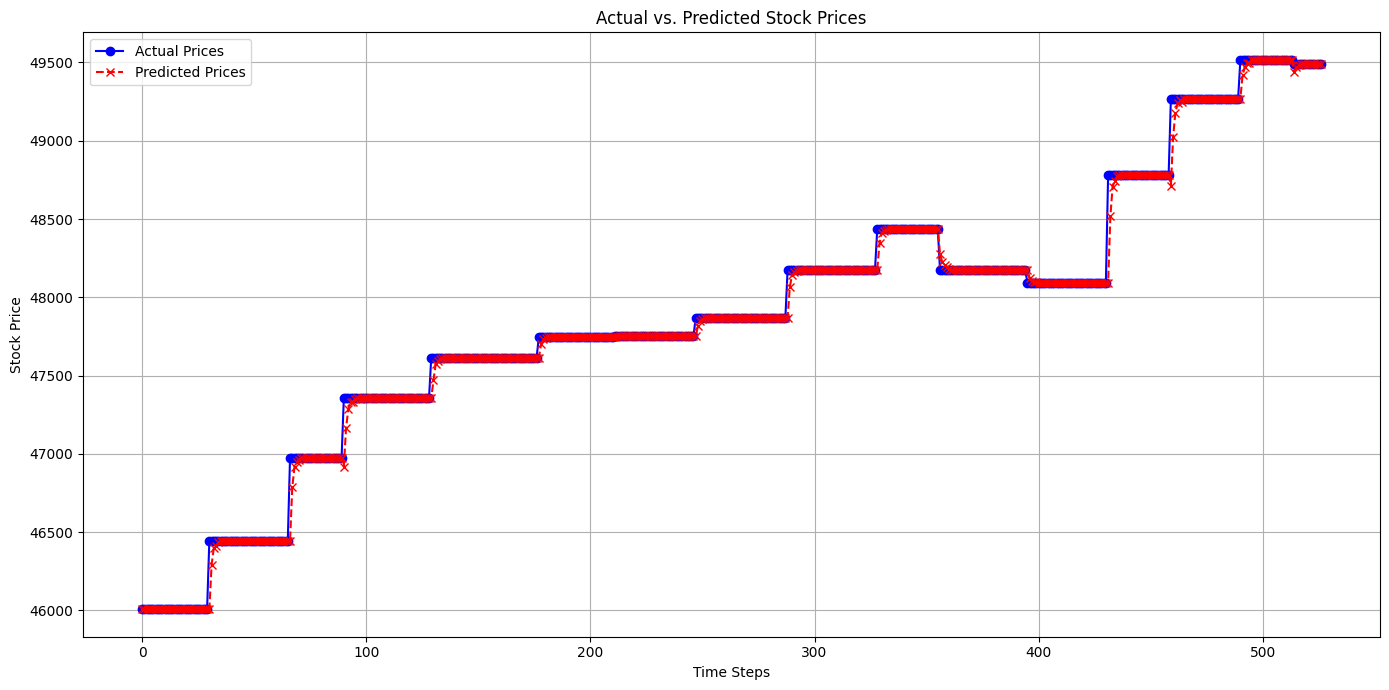

In [60]:
plt.figure(figsize=(14, 7))
plt.plot(actuals, label='Actual Prices', color='blue', marker='o', linestyle='-')
plt.plot(preds, label='Predicted Prices', color='red', marker='x', linestyle='--')
plt.title('Actual vs. Predicted Stock Prices')
plt.xlabel('Time Steps')
plt.ylabel('Stock Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### EVALUATION

In [61]:
if len(actuals) == 0 or len(preds) == 0:
    print("Error: 'actuals' or 'preds' lists are empty. Cannot compute metrics. Please check upstream data processing and merging steps.")
else:
    print("MAE:", mean_absolute_error(actuals, preds))
    print("RMSE:", np.sqrt(mean_squared_error(actuals, preds)))
    print("R2:", r2_score(actuals, preds))

MAE: 13.096379316956588
RMSE: 63.32535498693827
R2: 0.994878516895758
